In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rc('legend',fontsize=10)
import datetime

# Set colors
highlight_color = '#1ebeff'
contrast_color = '#fae042'
medal_colors = ['gold', 'silver', 'chocolate']
medal_names = ['Gold', 'Silver', 'Bronze']
from matplotlib.colors import LinearSegmentedColormap
kaggle_palette = LinearSegmentedColormap.from_list("", [highlight_color,  '#ffffff', contrast_color])
plt.cm.register_cmap("kaggle_palette", kaggle_palette)

# Intro

---
This is an entry for the [Hidden Gems Notebooks Competition](https://www.kaggle.com/datasets/headsortails/notebooks-of-the-week-hidden-gems/discussion/317098?sort=recent-comments). Join in on the fun!

---

Although I am sure we are all here to learn and improve our Data Science skills, the gamification aspect of the Kaggle platform with its ranking system is a prominent topic among a lot of Kagglers. On the one hand, the gamification makes it fun to keep coming back to the platform and can be a motivator to many Kagglers to improve their models and leaderboard scores, to share their concepts in notebooks or to get involved in discussions. On the other hand, the discussion on how to get upvotes, which are relevant to progress in the "Notebooks" category, can sometimes get a little bit heated when Kagglers try to get upvotes by other methods than to just produce quality content - e.g. Kagglers spamming comments to promote their notebooks (see [this discussion](https://www.kaggle.com/competitions/m5-forecasting-accuracy/discussion/150568)). It goes even as far that off-topic self promotion and upvote collusion are mentioned to be avoided in the [Kaggle Community Guidelines](https://www.kaggle.com/community-guidelines). 

Although my impression is that the majority of Kagglers don't try to game the progression system and try to put out quality content, there also seems to be a frustration or resignation about low upvote counts (see [this discussion](https://www.kaggle.com/discussions/questions-and-answers/178572) or [this discussion](https://www.kaggle.com/competitions/tabular-playground-series-jan-2022/discussion/302569)). What is even often seen in competitions is that [notebooks can have more forks than upvotes](https://www.kaggle.com/competitions/tabular-playground-series-jan-2022/discussion/298245). So, **the discussion around upvotes seems to be of interest**.

The aim behind the [Hidden Gems](https://www.kaggle.com/general/150603) series is to shine some light on underrated notebooks.

> "Not all the notebooks get the attention that they deserve. Not all the notebooks get the views, the feedback from the community and the upvotes that the quality would deserve. And I'm trying my little bit to rectify that situation. [...] I'm trying to highlight those in my weekly posts and **I'm trying to get those notebooks and those authors the attention that they deserve.** - [Heads or Tails in Kaggle Hidden Gems: 100th episode Livestream](https://www.youtube.com/watch?v=o__J3bkp2PQ)

So, let's analyse what happens to your notebook once it is mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series. How many upvotes can you expect? Will your notebook be awarded with a gold medal?

In addition to the [Notebooks of the Week - Hidden Gems dataset](https://www.kaggle.com/datasets/headsortails/notebooks-of-the-week-hidden-gems?sort=recent-comments), we will be using the [Meta Kaggle dataset](https://www.kaggle.com/datasets/kaggle/meta-kaggle).

In [2]:
###############################################################################################
# First we need to do a little bit of data preparations in the form of merging a few dataframes
# and creating new columns and renaming columns to make the merging possible
###############################################################################################

# Load kaggle_hidden_gems.csv
gems_df = pd.read_csv("../input/notebooks-of-the-week-hidden-gems/kaggle_hidden_gems.csv")
gems_df = gems_df[['vol', 'date', 'notebook', 'title', 'author_name', 'notes']]

# Load Kernels.csv
kernels_df = pd.read_csv("../input/meta-kaggle/Kernels.csv")
kernels_df.rename(columns={"CurrentKernelVersionId": "KernelVersionId"}, inplace=True)

# Merge Users.csv and Kernels.csv to get the 'UserName' column
users_df = pd.read_csv("../input/meta-kaggle/Users.csv")
users_df.rename(columns={"Id": "AuthorUserId"}, inplace=True)
users_df = users_df[['AuthorUserId', 'UserName']]
kernels_df = kernels_df.merge(users_df, on = 'AuthorUserId', how='left')

# Save headsortails user id for later
headsortails_uid = users_df[users_df.UserName == 'headsortails'].AuthorUserId.values[0]
del users_df

# Create new column 'notebook' with the new column 'UserName' to merge it with gems_df
kernels_df['notebook'] = kernels_df[['UserName', 'CurrentUrlSlug']].apply(lambda row: "https://www.kaggle.com/" + '/'.join(row.values.astype(str)), axis=1)
gems_df = gems_df.merge(kernels_df, on='notebook', how='left')
del kernels_df

# Merge gems_df with KernelVersions.csv to get column 'ScriptId'
kernelversions_df = pd.read_csv("../input/meta-kaggle/KernelVersions.csv")
kernelversions_df = kernelversions_df[['Id', 'ScriptId']]
kernelversions_df.rename(columns={"Id": "KernelVersionId"}, inplace=True)
gems_df = gems_df.merge(kernelversions_df, on='KernelVersionId', how='left')

# Merge kernelvotes_df with KernelVersions.csv to get column 'ScriptId'
kernelvotes_df = pd.read_csv("../input/meta-kaggle/KernelVotes.csv")
kernelvotes_df = kernelvotes_df.merge(kernelversions_df, on='KernelVersionId', how='left')
del kernelversions_df

# Merge kernelvotes_df with gems_df
kernelvotes_df = kernelvotes_df.merge(gems_df, on='ScriptId', how='left')

###############################################################################################
# Next we will modify the kernelvotes_df in a way that we can extact some insights
###############################################################################################

# Only get kernels that are hidden gems
kernelvotes_df = kernelvotes_df[kernelvotes_df.date.notna()]
# Reduce columns to relevant ones 
kernelvotes_df = kernelvotes_df[['ScriptId', 'MadePublicDate', 'date', 'VoteDate']]
# Format datetime
kernelvotes_df['date'] = pd.to_datetime(kernelvotes_df.date, format = '%Y-%m-%d')
kernelvotes_df['VoteDate'] = pd.to_datetime(kernelvotes_df.VoteDate, format = '%m/%d/%Y')
kernelvotes_df['MadePublicDate'] = pd.to_datetime(kernelvotes_df.MadePublicDate, format = '%m/%d/%Y')

# Create new features
kernelvotes_df['previous_upvote'] = kernelvotes_df['date'] > kernelvotes_df['VoteDate']
kernelvotes_df['upvotes_one_week_prior_to_mention'] = (kernelvotes_df['date'] > kernelvotes_df['VoteDate']) & ((kernelvotes_df['date'] - datetime.timedelta(days=7)) < kernelvotes_df['VoteDate'])
kernelvotes_df['new_upvote'] = kernelvotes_df['date'] <= kernelvotes_df['VoteDate']
kernelvotes_df['new_upvote_on_day_of_mention'] = kernelvotes_df['date'] == kernelvotes_df['VoteDate']
kernelvotes_df['new_upvote_within_one_week'] = (kernelvotes_df['date'] < kernelvotes_df['VoteDate']) & (kernelvotes_df['VoteDate'] < (kernelvotes_df['date'] + datetime.timedelta(days=7)))
kernelvotes_df['days_since_made_public'] = (kernelvotes_df['VoteDate'] - kernelvotes_df['MadePublicDate']).astype('timedelta64[D]')
kernelvotes_df['days_since_mentioned'] = (kernelvotes_df['VoteDate'] - kernelvotes_df['date']).astype('timedelta64[D]')

###############################################################################################
# Finally, we will create new dataframe by grouping the votes by 'ScriptId'
###############################################################################################
kernelvotes_grouped_df = kernelvotes_df.groupby('ScriptId').sum()

# Merge it to the gems_df
gems_df = gems_df.merge(kernelvotes_grouped_df, on='ScriptId')

# Format datetime
gems_df['date'] = pd.to_datetime(gems_df.date, format = '%Y-%m-%d')
gems_df['MedalAwardDate'] = pd.to_datetime(gems_df.MedalAwardDate, format = '%m/%d/%Y')
gems_df['MadePublicDate'] = pd.to_datetime(gems_df.MadePublicDate, format = '%m/%d/%Y')
# Create new features
gems_df['medal_awarded_after_mention'] = gems_df['date'] <= gems_df['MedalAwardDate']
gems_df['medal_awarded_one_week_after_mention'] = (gems_df['date'] <= gems_df['MedalAwardDate']) & (gems_df['MedalAwardDate'] < (gems_df['date'] + datetime.timedelta(days=7)))
gems_df['days_since_series_start'] = (gems_df['date'] - gems_df.iloc[0].date).astype('timedelta64[D]')
gems_df['days_to_medal'] = (gems_df['MedalAwardDate'] - gems_df['MadePublicDate']).astype('timedelta64[D]')
gems_df['days_since_mention'] = (pd.Timestamp.today() - gems_df['date']).astype('timedelta64[D]')
gems_df['days_to_mention'] = (gems_df['date'] - gems_df['MadePublicDate']).astype('timedelta64[D]')
gems_df['days_to_today'] = (pd.Timestamp.today() - gems_df['MadePublicDate']).astype('timedelta64[D]')

drop_cols = ['Id', 'KernelVersionId', 'AuthorUserId', 'ForkParentKernelVersionId', 'ForumTopicId', 'FirstKernelVersionId','CreationDate', 'CurrentUrlSlug', 'EvaluationDate', 'IsProjectLanguageTemplate','TotalViews', 'TotalComments']
gems_df.drop(drop_cols, axis=1, inplace=True)

#display(gems_df.head())

# Characteristics of a Hidden Gem

So, what is a "Hidden Gem"? From what I understand, to qualify as a "Hidden Gem" a notebook must be of high quality but without the amount of upvotes a high quality notebook would deserve. 

If we look at some statistics of the Hidden Gems, we can see that the median upvote count prior to being mentioned in the series is 24 upvotes. Depending on the upvotes (e.g. upvotes by novices, self-votes) that would mean **a Hidden Gem would be a silver medal notebook or a bronze notebook close to the silver medal.**

Furthermore, it takes roughly 5 months (153 days) for a Hidden Gem to be discovered and shared with the community. That is also inline with the fact that these Hidden Gems receive almost no activity prior to the mention. The median count of new upvotes the week leading up to the mention in the series is 0 upvotes.

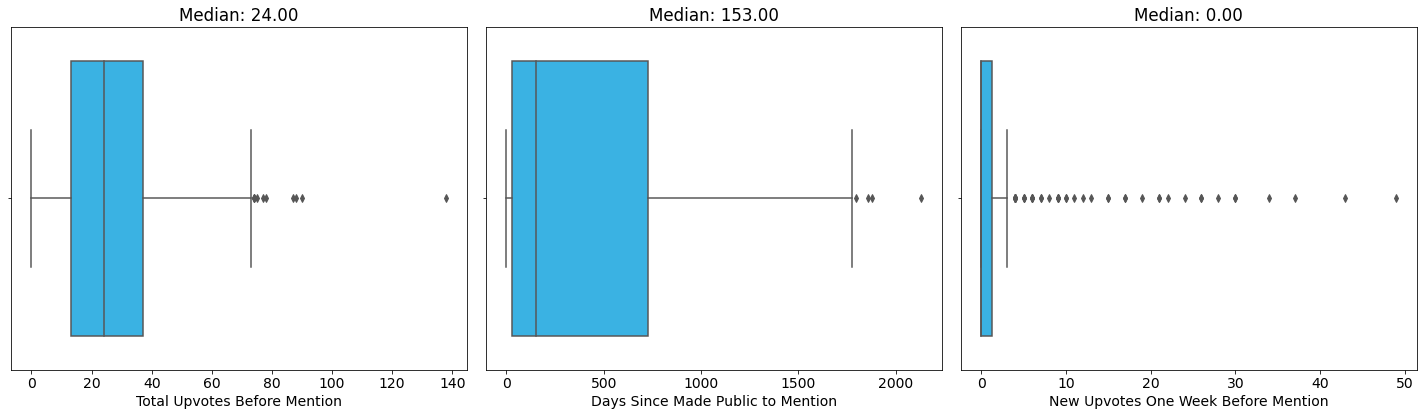

In [3]:
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.boxplot(x=gems_df.previous_upvote, color=highlight_color, ax=ax[0])
ax[0].set_title(f"Median: {gems_df.previous_upvote.median():.2f}")
ax[0].set_xlabel('Total Upvotes Before Mention')
sns.boxplot(x=gems_df.days_to_mention, color=highlight_color, ax=ax[1])
ax[1].set_title(f"Median: {gems_df.days_to_mention.median():.2f}")
ax[1].set_xlabel('Days Since Made Public to Mention')

sns.boxplot(x=gems_df.upvotes_one_week_prior_to_mention, color=highlight_color, ax=ax[2])
ax[2].set_title(f"Median: {gems_df.upvotes_one_week_prior_to_mention.median():.2f}")
ax[2].set_xlabel('New Upvotes One Week Before Mention')
plt.tight_layout()
plt.show()

As with any good ol' dataset, this dataset seems to also contain some outliers:
* One notebook has had 138 upvotes prior to being mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series. 
* Two notebooks were shared the same day they were made public.

One could argue whether these notebooks were truly *hidden* gems or just plain *out in the open* gems. But this is not the objective of this notebook and we are not going to make that argument.

In [4]:
gems_df[gems_df.previous_upvote > 100]

,vol,date,notebook,title,author_name,notes,MadePublicDate,Medal,MedalAwardDate,TotalVotes,UserName,ScriptId,previous_upvote,upvotes_one_week_prior_to_mention,new_upvote,new_upvote_on_day_of_mention,new_upvote_within_one_week,days_since_made_public,days_since_mentioned,medal_awarded_after_mention,medal_awarded_one_week_after_mention,days_since_series_start,days_to_medal,days_since_mention,days_to_mention,days_to_today
92,32,2020-12-15,https://www.kaggle.com/jonathanbouchet/f1-data...,F1 Data analysis,Jonathan Bouchet,NaN,2017-12-02,1.0,2021-06-18,168.0,jonathanbouchet,467514.0,138,0,27,2,3,92359.0,-90626.0,True,False,217.0,1294.0,483.0,1109.0,1592.0


In [5]:
gems_df[gems_df.days_to_mention == 0]

,vol,date,notebook,title,author_name,notes,MadePublicDate,Medal,MedalAwardDate,TotalVotes,UserName,ScriptId,previous_upvote,upvotes_one_week_prior_to_mention,new_upvote,new_upvote_on_day_of_mention,new_upvote_within_one_week,days_since_made_public,days_since_mentioned,medal_awarded_after_mention,medal_awarded_one_week_after_mention,days_since_series_start,days_to_medal,days_since_mention,days_to_mention,days_to_today
166,58,2021-06-15,https://www.kaggle.com/ligtfeather/swinformer-...,Swinformer + CutMix + AMP + Accelerate + W&B,Tanishq Gautam,NaN,2021-06-15,1.0,2021-06-17,94.0,ligtfeather,17748022.0,0,0,93,36,26,1632.0,1632.0,True,True,399.0,2.0,301.0,0.0,301.0
223,77,2021-10-26,https://www.kaggle.com/tanlikesmath/petfinder-...,Petfinder Pawpularity EDA & fastai starter,ilovescience,NaN,2021-10-26,1.0,2021-10-28,247.0,tanlikesmath,21485799.0,0,0,247,39,39,7713.0,7713.0,True,True,532.0,2.0,168.0,0.0,168.0


# Upvotes

Let's plot the upvote timeline for a few notebooks mentioned in the series.

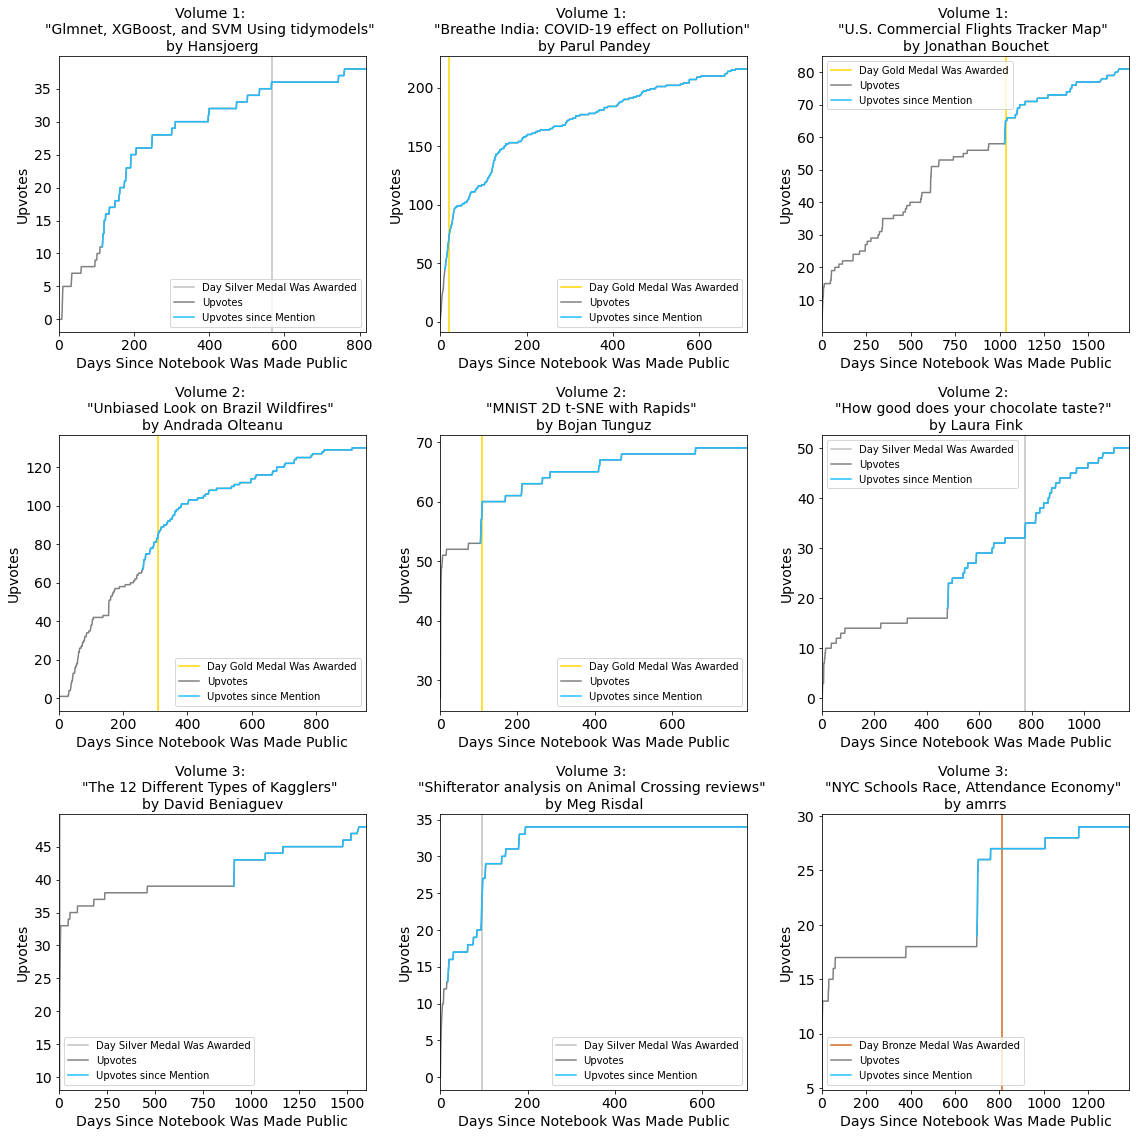

In [6]:
temp = kernelvotes_df[kernelvotes_df.days_since_made_public>=0].groupby('ScriptId').days_since_made_public.value_counts().to_frame()#
temp.columns = ['upvotes']
temp.reset_index(drop=False, inplace=True)
temp = temp.pivot(index='days_since_made_public', columns='ScriptId').upvotes.fillna(0)
temp = temp.cumsum()

def plot_upvote_timeline(script_id):
    f, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
    sns.lineplot(data=temp, x='days_since_made_public', y=script_id, label='Upvotes', color='grey')
    sns.lineplot(data=temp[temp.index>=gems_df[gems_df.ScriptId == script_id].days_to_mention.values[0]], x='days_since_made_public', y=script_id, label='Upvotes since Mention', color=highlight_color)
    ax.set_xlim([0, gems_df[gems_df.ScriptId == script_id].days_to_today.values[0]])
    ax.set_title(f'"{gems_df[gems_df.ScriptId == script_id].title.values[0]}" by {gems_df[gems_df.ScriptId == script_id].author_name.values[0]}')
    ax.set_ylabel('Upvotes')
    ax.set_xlabel('Days Since Notebook Was Made Public')
    if gems_df[gems_df.ScriptId == script_id].Medal.values[0] == gems_df[gems_df.ScriptId == script_id].Medal.values[0]: #check if nan
        ax.axvline(x=gems_df[gems_df.ScriptId == script_id].days_to_medal.values[0], 
                   color=medal_colors[int(gems_df[gems_df.ScriptId == script_id].Medal.values[0]-1)], 
                   label=f'Day {medal_names[int(gems_df[gems_df.ScriptId == script_id].Medal.values[0]-1)]} Medal Was Awarded')
    plt.legend()
    plt.show()
    
num_vols = 3
f, ax = plt.subplots(nrows=num_vols, ncols=3, figsize=(16, 16))

for i in range(num_vols):
    for j, script_id in enumerate(gems_df[gems_df.vol == (i+1)].ScriptId.values):

        ax[i,j].axvline(x=gems_df[gems_df.ScriptId == script_id].days_to_medal.values[0], 
           color=medal_colors[int(gems_df[gems_df.ScriptId == script_id].Medal.values[0]-1)], 
           label=f'Day {medal_names[int(gems_df[gems_df.ScriptId == script_id].Medal.values[0]-1)]} Medal Was Awarded')

        sns.lineplot(data=temp, x='days_since_made_public', y=script_id, label='Upvotes', color='grey', ax=ax[i,j])
        sns.lineplot(data=temp[temp.index>=gems_df[gems_df.ScriptId == script_id].days_to_mention.values[0]], x='days_since_made_public', y=script_id, label='Upvotes since Mention', color=highlight_color, ax=ax[i,j])
        ax[i,j].set_xlim([0, gems_df[gems_df.ScriptId == script_id].days_to_today.values[0]])
        ax[i,j].set_title(f'Volume {i+1}: \n"{gems_df[gems_df.ScriptId == script_id].title.values[0]}" \nby {gems_df[gems_df.ScriptId == script_id].author_name.values[0]}', fontsize=14)
        ax[i,j].set_ylabel('Upvotes')
        ax[i,j].set_xlabel('Days Since Notebook Was Made Public')
plt.legend()
plt.tight_layout()
plt.show()

We can see that for some of the notebooks, the mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series results in a rising edge of the upvote count timeline after a long period of upvote stagnation.

If we look at the mean upvote timeline after a notebook was mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series as shown below, we can see that shortly after the mention the upvote gain is largest and decreases after while. **On the day of the mention, a Hidden Gem receives two upvotes on average and within a week of being mentioned it receives 7 upvotes on average.**

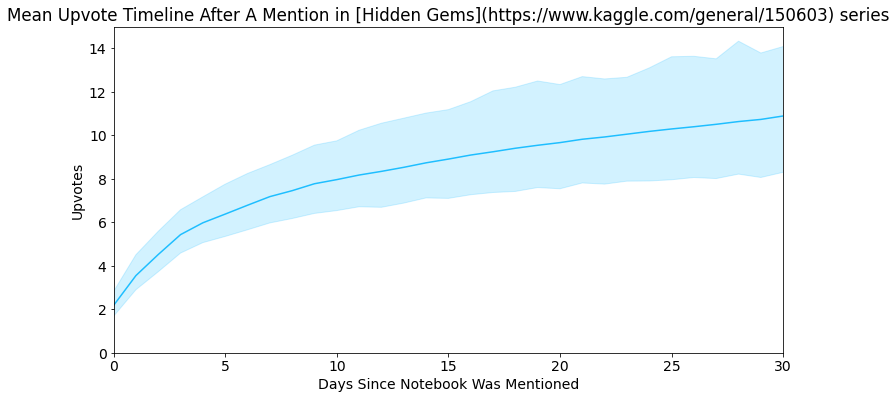

In [7]:
temp2 = kernelvotes_df[kernelvotes_df.days_since_mentioned>=0].groupby('ScriptId').days_since_mentioned.value_counts().to_frame()#
temp2.columns = ['upvotes']
temp2.reset_index(drop=False, inplace=True)
temp2 = temp2.pivot(index='days_since_mentioned', columns='ScriptId').upvotes.fillna(0)
temp2 = temp2.cumsum()
temp2 =temp2.stack().to_frame()
temp2.columns = ['upvotes']
temp2.reset_index(drop=False, inplace=True)

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
sns.lineplot(data = temp2, x = 'days_since_mentioned', y = 'upvotes', color=highlight_color)
ax.set_xlim([0, 30])
ax.set_ylim([0, 15])
ax.set_title(f'Mean Upvote Timeline After A Mention in [Hidden Gems](https://www.kaggle.com/general/150603) series')
ax.set_ylabel('Upvotes')
ax.set_xlabel('Days Since Notebook Was Mentioned')
plt.show()

# Medals
22% (67/300) of mentioned notebooks were awarded a medal one week after being mentioned. Most of the newly awarded medals were silver medals, which is inline with the finding that most Hidden Gems must be either silver medal notebooks or bronze medal notebooks close to the silver medal. With an average of 7 new upvotes within the first week after being featured in the [Hidden Gems](https://www.kaggle.com/general/150603) series, it makes sense that **these notebooks are pushed from a bronze to a silver medal**.

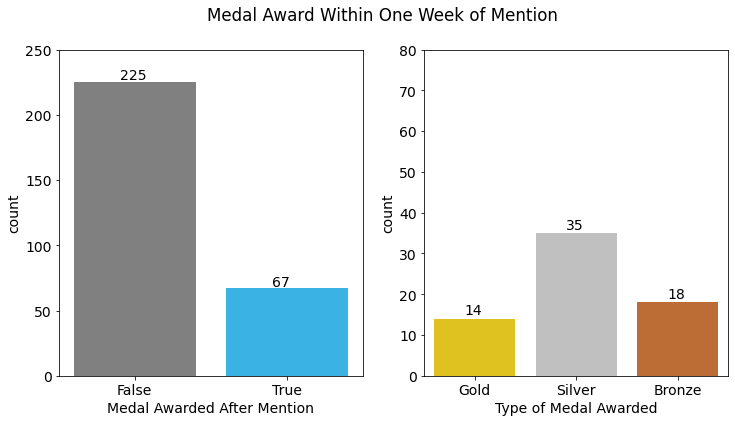

In [8]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.countplot(x = gems_df.medal_awarded_one_week_after_mention, palette = ['grey', highlight_color], ax=ax[0])
sns.countplot(x = gems_df[gems_df.medal_awarded_one_week_after_mention].Medal, palette = medal_colors, ax=ax[1])
for p in ax[0].patches:
        ax[0].annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()+2))
        
for p in ax[1].patches:
        ax[1].annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()+1))
ax[0].set_ylim([0, 250])
ax[0].set_xlabel('Medal Awarded After Mention')

ax[1].set_ylim([0, 80])     
ax[1].set_xticklabels(medal_names)
ax[1].set_xlabel('Type of Medal Awarded')

plt.suptitle('Medal Award Within One Week of Mention')
plt.show()

# Edge Case Analysis
Let's look at the edge cases of this analysis: Which notebooks received the most upvotes within one week and which notebooks received the least upvotes in total.

## Most Upvotes Within One Week
Let's look at the notebooks with the most upvotes within the week of the mention first.

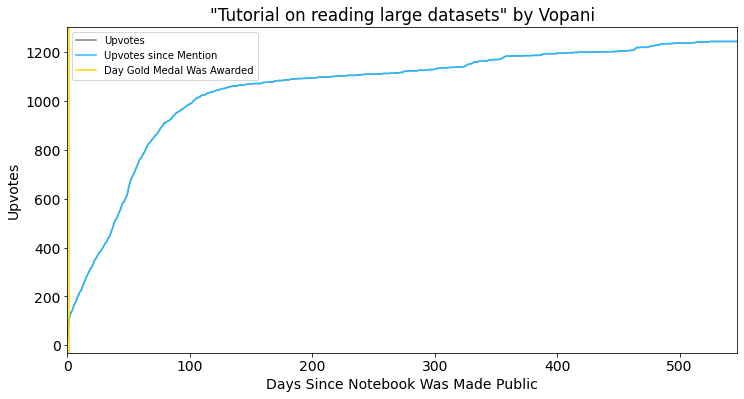

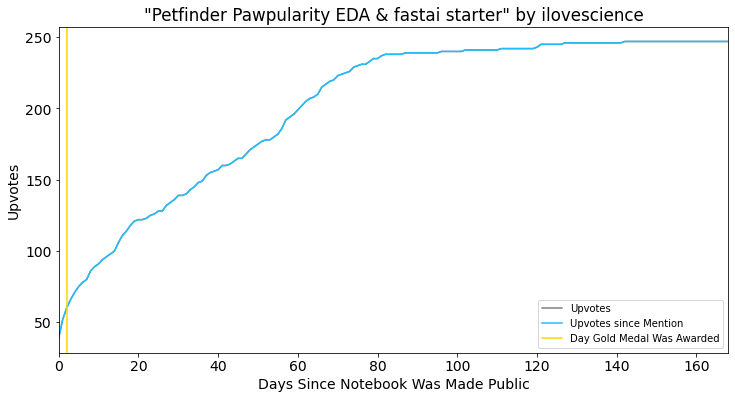

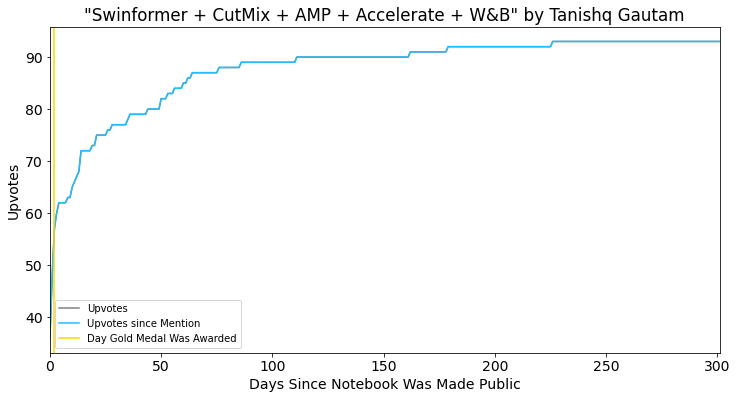

In [9]:
for script_id in gems_df.sort_values(by='new_upvote_within_one_week', ascending=False).head(3).ScriptId.values:
    plot_upvote_timeline(script_id)

In [10]:
def highlight_cols(s):
    return 'background-color: %s' % highlight_color

gems_df.sort_values(by='new_upvote_within_one_week', ascending=False)[['ScriptId', 'UserName', 'author_name','title',  'MadePublicDate', 'date', 'days_to_mention', 
                                                                         'Medal', 'MedalAwardDate',    'days_to_medal',   
       'TotalVotes', 
        'previous_upvote',
       'upvotes_one_week_prior_to_mention',
    'new_upvote',
       'new_upvote_within_one_week', 
                  ]].head(3).style.format({"ScriptId": "{:.0f}",
                                          "MadePublicDate" : "{:%Y-%m-%d}",
                                          "date" : "{:%Y-%m-%d}",
                                           "days_to_mention": "{:.0f}",
                                           "Medal": "{:.0f}",
                                           "MedalAwardDate" : "{:%Y-%m-%d}",
                                           "days_to_medal": "{:.0f}",
                                           "TotalVotes": "{:.0f}",}).applymap(highlight_cols, subset=['days_to_mention']).hide_index()


ScriptId,UserName,author_name,title,MadePublicDate,date,days_to_mention,Medal,MedalAwardDate,days_to_medal,TotalVotes,previous_upvote,upvotes_one_week_prior_to_mention,new_upvote,new_upvote_within_one_week
12234125,rohanrao,Vopani,Tutorial on reading large datasets,2020-10-12,2020-10-13,1,1,2020-10-13,1,1246,30,30,1214,86
21485799,tanlikesmath,ilovescience,Petfinder Pawpularity EDA & fastai starter,2021-10-26,2021-10-26,0,1,2021-10-28,2,247,0,0,247,39
17748022,ligtfeather,Tanishq Gautam,Swinformer + CutMix + AMP + Accelerate + W&B,2021-06-15,2021-06-15,0,1,2021-06-17,2,94,0,0,93,26


We can see that the notebooks with the most upvotes within one week after mention have in common that they were mentioned close to the date of being made public: Either one day after being made public or even on the same day. As mentioned before, one could now argue whether these notebooks were truly *hidden* or not.

## No Upvotes Since Mention
Let's also look at the notebooks that have not received any upvotes since the mention. Since the [Meta Kaggle dataset](https://www.kaggle.com/datasets/kaggle/meta-kaggle) was last updated 17 days ago (as the time of writing), we will only look at "Hidden Gems" volumes that were published before that date.

We can see that as of the time of this analysis, the notebook [CTDS - Subtitles exploration](https://www.kaggle.com/crazydiv/ctds-subtitles-exploration) did not receive any additional upvotes since the mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series.

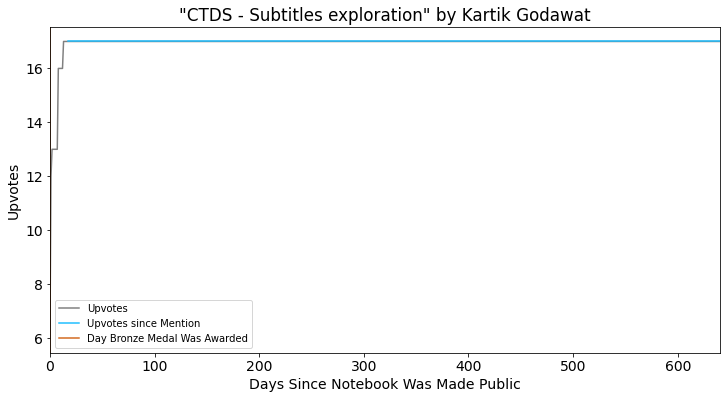

In [11]:
for script_id in gems_df[(gems_df.new_upvote == 0) & (gems_df.days_since_mention > 17)].ScriptId.values:
    plot_upvote_timeline(script_id)

What might be interesting is that this notebook was featured in a special edition of the [Hidden Gems](https://www.kaggle.com/general/150603) series.
> This week's episode is a special edition on the recently finished [Chai Time Data Science (CTDS) show Notebooks competition](https://www.kaggle.com/rohanrao/chai-time-data-science/discussion/168310). All three featured Notebooks will be outstanding contributions to this contest.

While the notebook *'Making perfect "Chai" and other tales :)'* of that week's volume received 19 upvotes since the mention out of which 5 upvotes where received within the first week after mention, the other two notebooks in that volume received surprisingly low upvotes: one received no upvotes - as we just saw - and the other only one new upvote.

In [12]:
gems_df[gems_df.vol == 12][[ 'vol', 'notes', 'ScriptId', 'UserName', 'author_name','title',  'MadePublicDate', 'date', 'days_to_mention',      'new_upvote',
       'TotalVotes', 
        'previous_upvote',
       'upvotes_one_week_prior_to_mention',

       'new_upvote_within_one_week',
                  ]].style.format({"ScriptId": "{:.0f}",
                                          "MadePublicDate" : "{:%Y-%m-%d}",
                                          "date" : "{:%Y-%m-%d}",
                                           "days_to_mention": "{:.0f}",
                                           "Medal": "{:.0f}",
                                           "MedalAwardDate" : "{:%Y-%m-%d}",
                                           "days_to_medal": "{:.0f}",
                                           "TotalVotes": "{:.0f}",}).applymap(highlight_cols, subset=['vol', 'notes', 'new_upvote']).hide_index()

vol,notes,ScriptId,UserName,author_name,title,MadePublicDate,date,days_to_mention,new_upvote,TotalVotes,previous_upvote,upvotes_one_week_prior_to_mention,new_upvote_within_one_week
12,This week's episode is a special edition on the recently finished [Chai Time Data Science (CTDS) show Notebooks competition](https://www.kaggle.com/rohanrao/chai-time-data-science/discussion/168310). All three featured Notebooks will be outstanding contributions to this contest.,10252872,thedatabeast,Ramshankar Yadhunath,"Making perfect ""Chai"" and other tales :)",2020-06-25,2020-07-28,33,19,52,32,1,5
12,This week's episode is a special edition on the recently finished [Chai Time Data Science (CTDS) show Notebooks competition](https://www.kaggle.com/rohanrao/chai-time-data-science/discussion/168310). All three featured Notebooks will be outstanding contributions to this contest.,10597194,vrindaprabhu,Vrinda Prabhu,Does Twitter Chirp Chai?,2020-07-11,2020-07-28,17,1,17,15,0,1
12,This week's episode is a special edition on the recently finished [Chai Time Data Science (CTDS) show Notebooks competition](https://www.kaggle.com/rohanrao/chai-time-data-science/discussion/168310). All three featured Notebooks will be outstanding contributions to this contest.,10610098,crazydiv,Kartik Godawat,CTDS - Subtitles exploration,2020-07-11,2020-07-28,17,0,18,17,1,0


# Correlations
[Heads or Tails](https://www.kaggle.com/headsortails) is the first ever Notebooks Grandmaster and has a large following on Kaggle. Let's see if the number of followers impacts the number of upvotes on a Hidden Gem notebook.

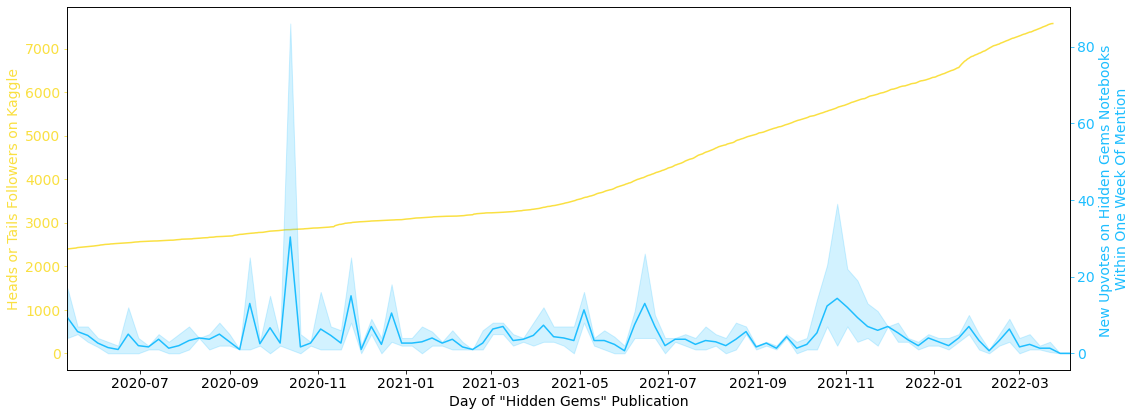

In [13]:
userfollowers_df = pd.read_csv("../input/meta-kaggle/UserFollowers.csv")

headsortails_followers = userfollowers_df[userfollowers_df.FollowingUserId == headsortails_uid].groupby('CreationDate').UserId.count().to_frame()

headsortails_followers.columns = ['new_followers']
headsortails_followers.reset_index(drop=False, inplace=True)

headsortails_followers['CreationDate'] = pd.to_datetime(headsortails_followers.CreationDate, format = '%m/%d/%Y')
headsortails_followers = headsortails_followers.sort_values(by='CreationDate')
headsortails_followers['total_followers'] = headsortails_followers['new_followers'].cumsum()

gems_df = pd.merge(gems_df, headsortails_followers[['CreationDate', 'total_followers']], left_on='date', right_on='CreationDate', how='left').drop('CreationDate', axis=1)

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
sns.lineplot(data=headsortails_followers, x='CreationDate', y='total_followers', color=contrast_color, ax=ax)
ax2 = ax.twinx()
sns.lineplot(data = gems_df, x = 'date', y = 'new_upvote_within_one_week', color=highlight_color, ax=ax2)
ax.set_xlim([gems_df.date.iloc[0], gems_df.date.iloc[-1]])
ax2.set_xlim([gems_df.date.iloc[0], gems_df.date.iloc[-1]])
ax.set_ylabel('Heads or Tails Followers on Kaggle', color=contrast_color)
ax.tick_params(axis='y', colors =contrast_color)
ax2.set_ylabel('New Upvotes on Hidden Gems Notebooks \nWithin One Week Of Mention', color=highlight_color)
ax2.tick_params(axis='y', colors = highlight_color)
plt.tight_layout()
ax.set_xlabel('Day of "Hidden Gems" Publication')
plt.show()

Even though [Heads or Tails](https://www.kaggle.com/headsortails)'s following has increased constantly over the past two years, it is difficult to say whether a mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series today will result in more upvotes than when the series was started about two years ago.

Let's see if there are any Hidden Gem notebook features that will impact the number of upvotes a notebook gets after a mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series.

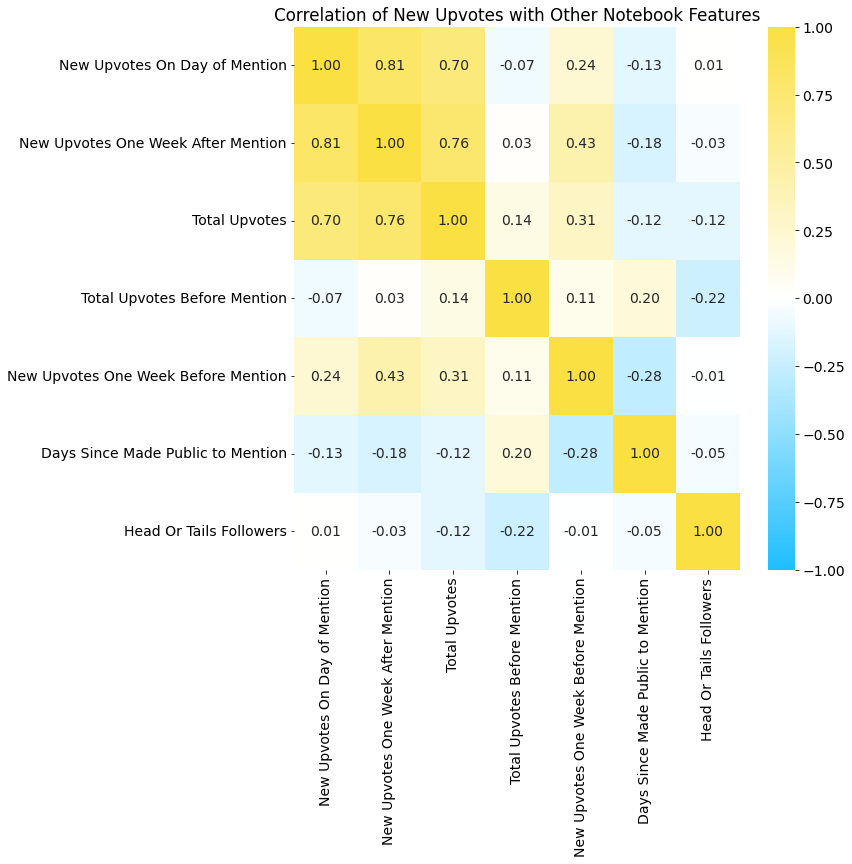

In [14]:
corrmat = gems_df[['new_upvote_on_day_of_mention', 'new_upvote_within_one_week','new_upvote',
                   'previous_upvote',
                   'upvotes_one_week_prior_to_mention', 
                   'days_to_mention', 
                   'total_followers']].corr()
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

sns.heatmap(corrmat, annot=True, fmt='.2f', cmap=kaggle_palette, vmin=-1, vmax=1)

ticklabels = [ 'New Upvotes On Day of Mention', 'New Upvotes One Week After Mention', 'Total Upvotes',
    'Total Upvotes Before Mention',
       'New Upvotes One Week Before Mention', 
       'Days Since Made Public to Mention', 'Head Or Tails Followers']
ax.set_xticklabels(labels=ticklabels)
ax.set_yticklabels(labels=ticklabels)
ax.set_title('Correlation of New Upvotes with Other Notebook Features')
plt.show()

Obviously, the number of new upvotes on the day of the mention, the number of upvotes within the week of the mention and the total upvotes of a notebook are highly correlated with each other. But as we have just suspected, the number of upvotes don't seem to correlate with the number of followers [Heads or Tails](https://www.kaggle.com/headsortails) has. Also, the number of upvotes a notebook has before the mention does not seem to impact the number of new upvotes a notebook gets.

However, the number of new upvotes a notebook gets the week prior to the mention and the number of days between the notebook was published and the notebook was mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series seem to be slightly related. Let's have a closer look.

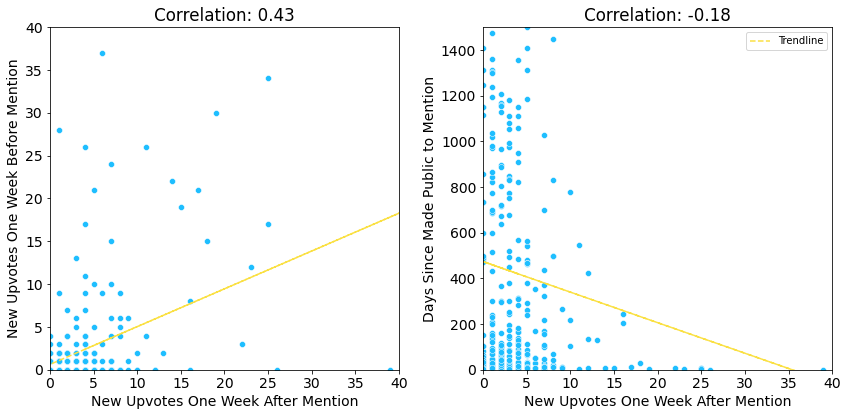

In [15]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.scatterplot(data=gems_df, x= 'new_upvote_within_one_week', y='upvotes_one_week_prior_to_mention', color=highlight_color, ax=ax[0])
# calc the trendline
x = gems_df.new_upvote_within_one_week
z = np.polyfit(x, gems_df.upvotes_one_week_prior_to_mention, 1)
p = np.poly1d(z)
ax[0].plot(x,p(x),contrast_color, linestyle='dashed', label='Trendline')
ax[0].set_xlim([0, 40])
ax[0].set_ylim([0, 40])
ax[0].set_xlabel('New Upvotes One Week After Mention')
ax[0].set_ylabel('New Upvotes One Week Before Mention')
ax[0].set_title(f'Correlation: {corrmat.new_upvote_within_one_week.loc["upvotes_one_week_prior_to_mention"]:.2f}')

sns.scatterplot(data=gems_df, x= 'new_upvote_within_one_week', y='days_to_mention', color=highlight_color, ax=ax[1])
# calc the trendline
z = np.polyfit(x, gems_df.days_to_mention.fillna(-999), 1)
p = np.poly1d(z)
ax[1].plot(x,p(x),contrast_color, linestyle='dashed', label='Trendline')
ax[1].set_xlim([0, 40])
ax[1].set_ylim([0, 1500])
ax[1].set_xlabel('New Upvotes One Week After Mention')
ax[1].set_ylabel('Days Since Made Public to Mention')
ax[1].set_title(f'Correlation: {corrmat.new_upvote_within_one_week.loc["days_to_mention"]:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Although the correlation is not necessarily visible in the above scatterplots, we can assume the following:
- Notebooks that receive more upvotes the week prior to the mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series also receive more upvotes during the week after the mention. The reason for this could be that the notebook still has some traffic or "Hotness" and is getting some attention without the mention.
- Notebooks that have a larger "discovery time" tend to get fewer new upvotes. This again seems to hint at the notebooks "Hotness".

If we re-look at the correlation matrix from above which only includes notebooks with zero "Hotness" (0 new upvotes the week prior to the mention), then we get the following correlation matrix. We can see that the number of new upvotes does not seem to correlate much with the other features at all. So, my guess is that **the number of new upvotes from a mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series depends on your notebook's "Hotness" and its quality.**

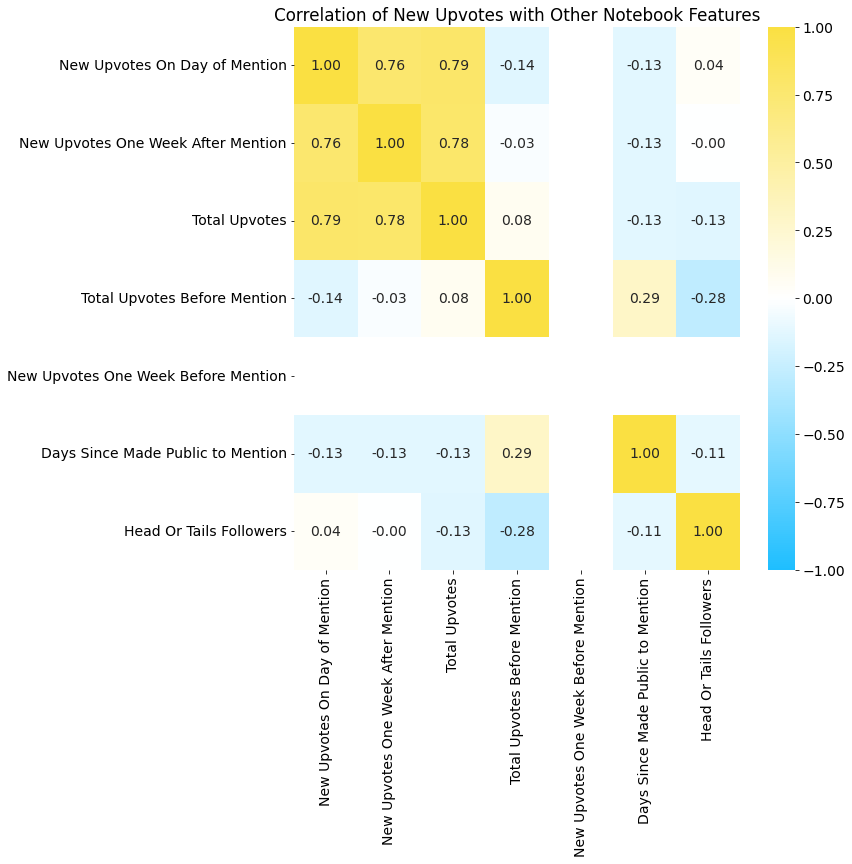

In [16]:
corrmat = gems_df[gems_df.upvotes_one_week_prior_to_mention == 0][['new_upvote_on_day_of_mention', 'new_upvote_within_one_week','new_upvote',
                   'previous_upvote',
                   'upvotes_one_week_prior_to_mention', 
                   'days_to_mention', 
                   'total_followers']].corr()
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

sns.heatmap(corrmat, annot=True, fmt='.2f', cmap=kaggle_palette, vmin=-1, vmax=1)

ticklabels = [ 'New Upvotes On Day of Mention', 'New Upvotes One Week After Mention', 'Total Upvotes',
    'Total Upvotes Before Mention',
       'New Upvotes One Week Before Mention', 
       'Days Since Made Public to Mention', 'Head Or Tails Followers']
ax.set_xticklabels(labels=ticklabels)
ax.set_yticklabels(labels=ticklabels)
ax.set_title('Correlation of New Upvotes with Other Notebook Features')
plt.show()

# My Experience
I was very lucky to have my notebook [Time Series Forecasting: Building Intuition](https://www.kaggle.com/code/iamleonie/time-series-forecasting-building-intuition/notebook) mentioned in the [Notebooks of the week: Hidden Gems - Vol. 43](https://www.kaggle.com/discussions/general/223149#1224424) on March 2nd, 2021.

It took my notebook 44 days after being made public to be mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series. This is a little bit faster than for other notebooks in this series as we have seen earlier.
As we now know most notebooks in the [Hidden Gems](https://www.kaggle.com/general/150603) series, my notebook at the time of mention in the series had 20 upvotes. We can see that the upvotes had saturated at that point and it had not received any upvotes the week prior to the mention. Within on week of the mention that notebook got 8 additional upvotes which pushed it from a bronze to a silver medal. You can see the rising edge and the silver medal award date right after the mention in the plot below.
This is also inline with the finding that a lot of notebooks get pushed to a silver medal after a mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series.

---
I would like to just quickly use this opportunity to thank [Heads or Tails](https://www.kaggle.com/headsortails) again for his great contribution to the Kaggle community and for using his voice and following to shine some light on our notebooks. Thank you!

---

**If you have a notebook that was mentioned in the [Hidden Gems](https://www.kaggle.com/general/150603) series before, I would like to know what your experience was like.**

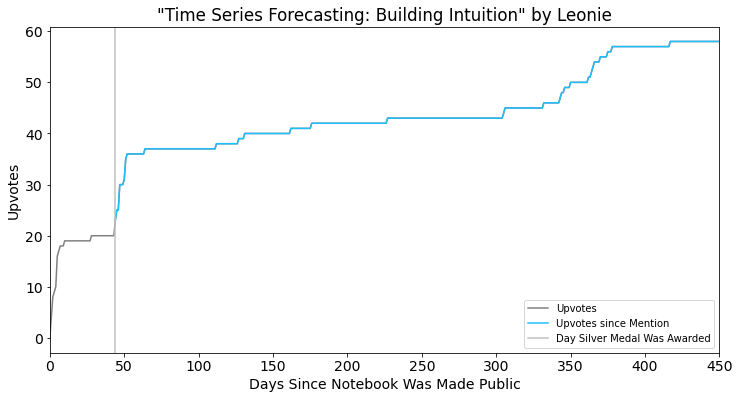

In [17]:
plot_upvote_timeline(gems_df[gems_df.UserName == 'iamleonie'].ScriptId.values[0])

# Summary

So, *what happens after a mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series?* Your notebook will most likely receive a few upvotes. Most likely on the day of the mention your notebook might get a couple of upvotes and a few more will trickle in within the week of that "Hidden Gems" volume. Since your Hidden Gem notebook is most likely a bronze medal on the edge of a silver medal, the mention in the [Hidden Gems](https://www.kaggle.com/general/150603) series could give your notebook push to a silver medal.

As a final note, I believe the [Hidden Gems](https://www.kaggle.com/general/150603) series is a great way to show some extra appreciation for high quality notebooks. This motivates Kagglers to keep producing high quality notebooks instead of off-topic self promotion or upvote collusion.